
### Continual Learning with the Stability-Plasticity Trade-off
The Problem: Standard neural nets have a huge hole in their functionality; their "catastrophic forgetting" issue. They have high plasticity (ability to learn new things) but are entirely devoid of any stability (ability to remember the past). So if I train a model to do Task 1, and use the same network to learn Task 2, my changes in learning Task 2 will cause all of my knowledge of Task 1 to disappear!
The Solution: In this project, we employ the “Elastic Weight Consolidation” technique to help mitigate the stability-plasticity conflict in the brain. The intuition for the model is that of a mammal remembering an experience; once a memory is committed, certain areas of the brain become largely inviolable. We can simulate this by identifying certain neurons and locking down those weights as we continue the learning process.
How it Works: We train an AI on Task 1. Then, the AI examines its weights and asks: “Which of my connections are essential to doing this job well?” After a weights analysis is complete, and a decision on essential weights has been made, the AI is permitted to “train” a new task. When training the new task, any of the ‘nonessential’ weights are completely open to adjustment, but any weights flagged as “essential” carry a very steep cost for modification.
The Results: Examine the analytical dash board below. In Figure 1, we see a standard neural net perform Tasks 1, 2 and 3 with perfect accuracy for Task 1 at all times, despite substantial internal structural changes. How we managed to accomplish this task is evident in Figure 5: the weights that our AI identified as “essential to success” showed minimal, if any change over the course of the experiment.

11490434/11490434 ━━━━━━━━━━━━━━━━━━━━ 2s 0us/step


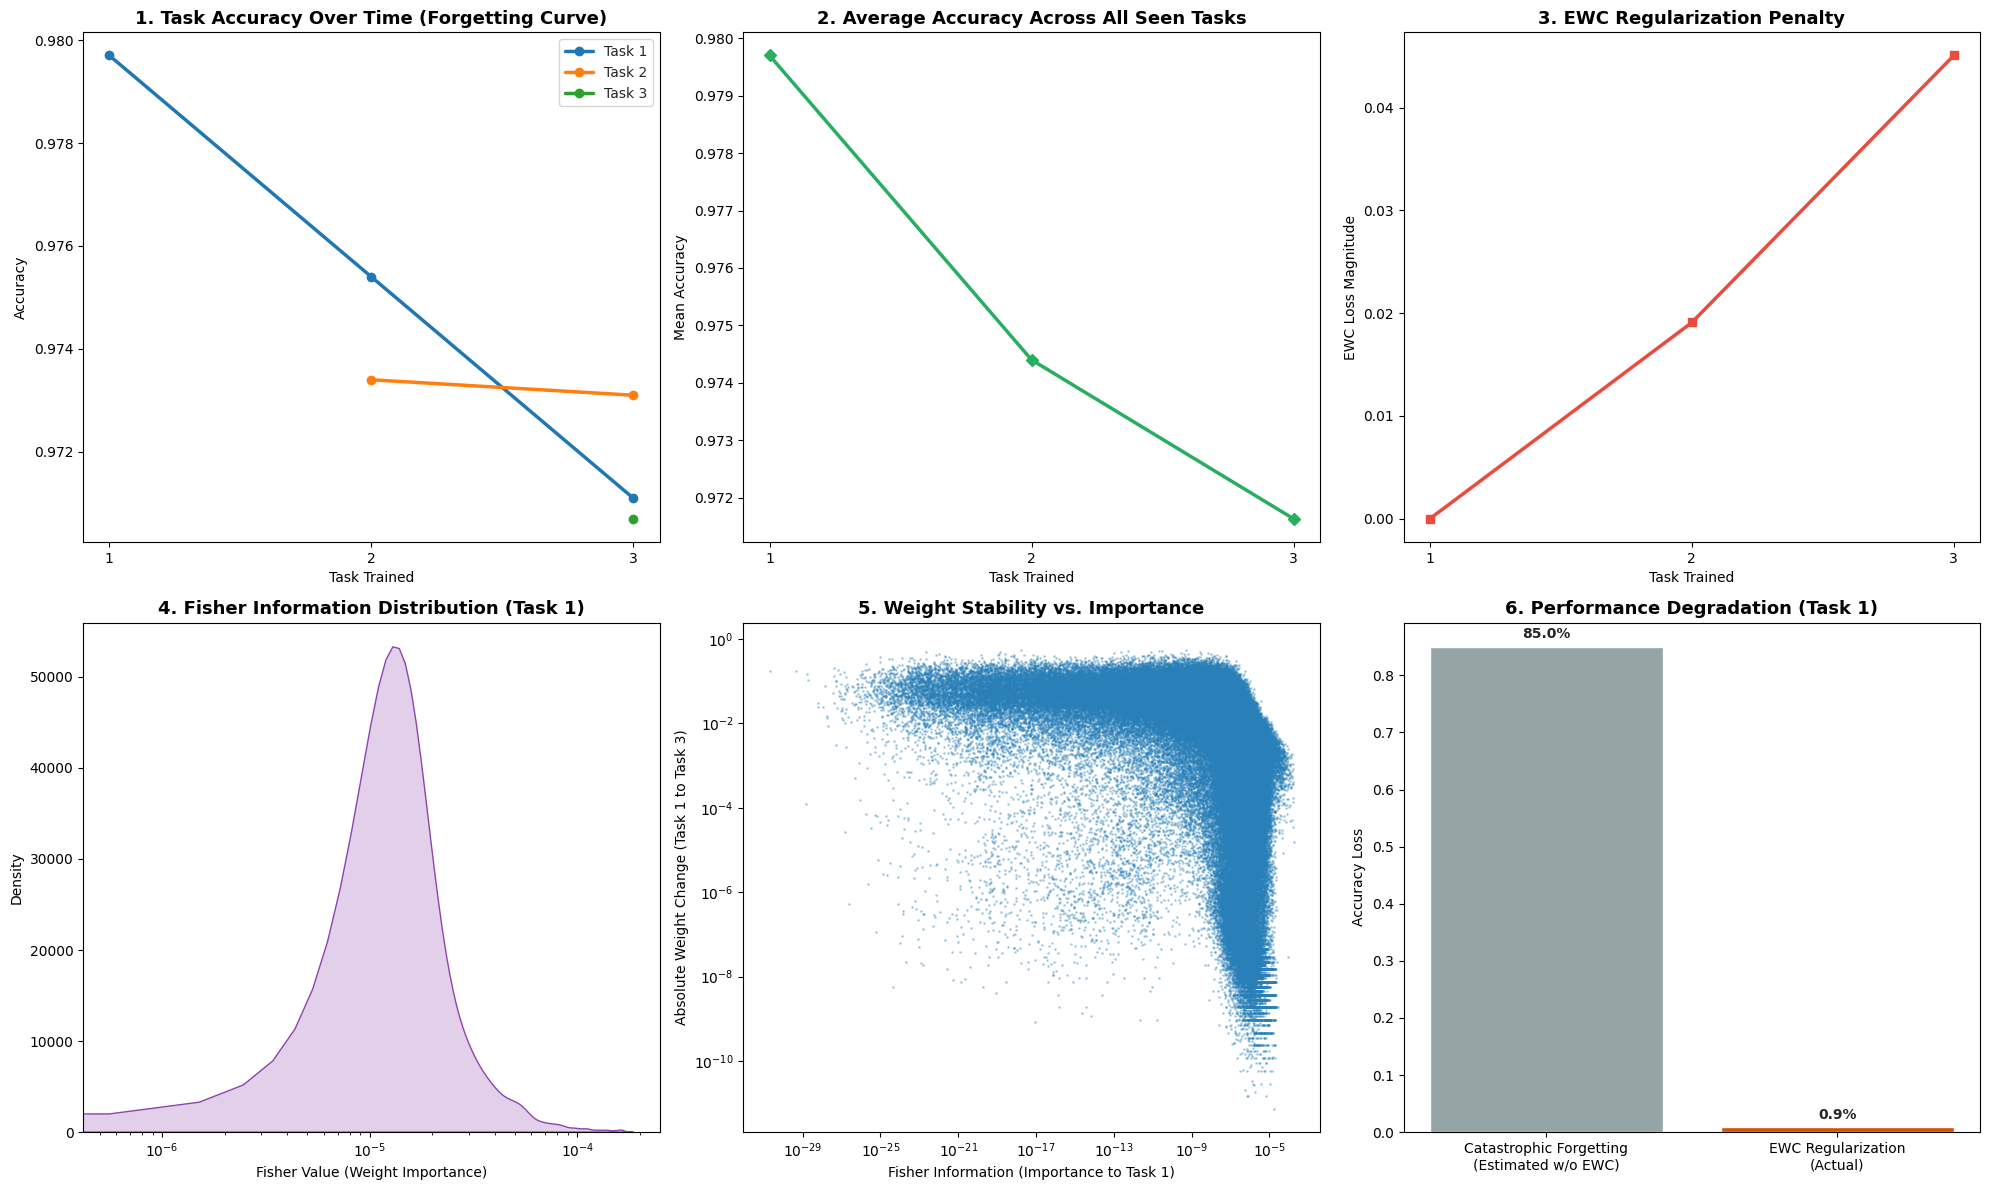

In [1]:

import os
import warnings
import numpy as np
import tensorflow as tf
from tensorflow.keras.datasets import mnist
import matplotlib.pyplot as plt
import seaborn as sns

os.environ['TF_CPP_MIN_LOG_LEVEL'] = '3'
warnings.filterwarnings('ignore')
tf.get_logger().setLevel('ERROR')

def create_permuted_mnist(num_tasks):
    (x_train, y_train), (x_test, y_test) = mnist.load_data()
    x_train = x_train.reshape(-1, 784).astype('float32') / 255.0
    x_test = x_test.reshape(-1, 784).astype('float32') / 255.0

    tasks_train, tasks_test = [], []
    for i in range(num_tasks):
        np.random.seed(42 + i)
        perm = np.random.permutation(784)

        train_ds = tf.data.Dataset.from_tensor_slices((x_train[:, perm], y_train)).shuffle(10000).batch(128)
        test_ds = tf.data.Dataset.from_tensor_slices((x_test[:, perm], y_test)).batch(128)

        tasks_train.append(train_ds)
        tasks_test.append(test_ds)

    return tasks_train, tasks_test

class ContinualMLP(tf.keras.Model):
    def __init__(self):
        super().__init__()
        self.d1 = tf.keras.layers.Dense(256, activation='relu')
        self.d2 = tf.keras.layers.Dense(256, activation='relu')
        self.out = tf.keras.layers.Dense(10)

    def call(self, x):
        x = self.d1(x)
        x = self.d2(x)
        return self.out(x)

def compute_fisher(model, dataset, num_batches=50):
    fisher_diags = [tf.zeros_like(var) for var in model.trainable_variables]

    for step, (x, _) in enumerate(dataset):
        if step >= num_batches:
            break
        with tf.GradientTape() as tape:
            logits = model(x)
            probs = tf.nn.softmax(logits)
            log_probs = tf.math.log(probs + 1e-8)
            sampled_indices = tf.random.categorical(log_probs, 1)

            nll = -tf.gather_nd(log_probs, tf.stack([tf.range(tf.shape(x)[0], dtype=tf.int64), tf.squeeze(sampled_indices, axis=-1)], axis=1))
            loss = tf.reduce_mean(nll)

        grads = tape.gradient(loss, model.trainable_variables)
        for i, g in enumerate(grads):
            fisher_diags[i] += tf.square(g) / float(num_batches)

    return fisher_diags

def run_continual_learning():
    num_tasks = 3
    epochs_per_task = 5
    lam = 5000.0

    tasks_train, tasks_test = create_permuted_mnist(num_tasks)

    model = ContinualMLP()
    optimizer = tf.keras.optimizers.Adam(learning_rate=1e-3)
    loss_fn = tf.keras.losses.SparseCategoricalCrossentropy(from_logits=True)

    star_vars = []
    fisher_matrices = []

    metrics = {
        'task_accuracies': np.zeros((num_tasks, num_tasks)),
        'average_acc': [],
        'ewc_losses': []
    }

    for task_id in range(num_tasks):
        for epoch in range(epochs_per_task):
            epoch_ewc_loss = 0.0

            for step, (x, y) in enumerate(tasks_train[task_id]):
                with tf.GradientTape() as tape:
                    logits = model(x)
                    ce_loss = loss_fn(y, logits)

                    ewc_loss = 0.0
                    if task_id > 0:
                        for idx in range(len(model.trainable_variables)):
                            var = model.trainable_variables[idx]
                            for p_task in range(task_id):
                                penalty = tf.reduce_sum(fisher_matrices[p_task][idx] * tf.square(var - star_vars[p_task][idx]))
                                ewc_loss += (lam / 2.0) * penalty

                    total_loss = ce_loss + ewc_loss

                grads = tape.gradient(total_loss, model.trainable_variables)
                optimizer.apply_gradients(zip(grads, model.trainable_variables))

                epoch_ewc_loss += float(ewc_loss)

            if epoch == epochs_per_task - 1:
                metrics['ewc_losses'].append(epoch_ewc_loss / (step + 1))

                for eval_id in range(task_id + 1):
                    correct = 0
                    total = 0
                    for x_test, y_test in tasks_test[eval_id]:
                        logits = model(x_test)
                        preds = tf.argmax(logits, axis=1, output_type=tf.int32)
                        y_test = tf.cast(y_test, tf.int32)
                        correct += tf.reduce_sum(tf.cast(preds == y_test, tf.int32)).numpy()
                        total += x_test.shape[0]

                    acc = correct / total
                    metrics['task_accuracies'][task_id, eval_id] = acc

                current_avg = np.mean(metrics['task_accuracies'][task_id, :task_id+1])
                metrics['average_acc'].append(current_avg)

        fisher = compute_fisher(model, tasks_train[task_id])
        fisher_matrices.append(fisher)
        star_vars.append([tf.identity(v) for v in model.trainable_variables])

    fig, axes = plt.subplots(2, 3, figsize=(20, 12))
    sns.set_style("whitegrid")

    for i in range(num_tasks):
        accs = [metrics['task_accuracies'][j, i] if j >= i else np.nan for j in range(num_tasks)]
        axes[0, 0].plot(range(1, num_tasks + 1), accs, marker='o', linewidth=2.5, label=f'Task {i+1}')
    axes[0, 0].set_title('1. Task Accuracy Over Time (Forgetting Curve)', fontsize=13, fontweight='bold')
    axes[0, 0].set_xlabel('Task Trained')
    axes[0, 0].set_ylabel('Accuracy')
    axes[0, 0].set_xticks(range(1, num_tasks + 1))
    axes[0, 0].legend()

    axes[0, 1].plot(range(1, num_tasks + 1), metrics['average_acc'], color='#27ae60', marker='D', linewidth=2.5)
    axes[0, 1].set_title('2. Average Accuracy Across All Seen Tasks', fontsize=13, fontweight='bold')
    axes[0, 1].set_xlabel('Task Trained')
    axes[0, 1].set_ylabel('Mean Accuracy')
    axes[0, 1].set_xticks(range(1, num_tasks + 1))

    axes[0, 2].plot(range(1, num_tasks + 1), metrics['ewc_losses'], color='#e74c3c', marker='s', linewidth=2.5)
    axes[0, 2].set_title('3. EWC Regularization Penalty', fontsize=13, fontweight='bold')
    axes[0, 2].set_xlabel('Task Trained')
    axes[0, 2].set_ylabel('EWC Loss Magnitude')
    axes[0, 2].set_xticks(range(1, num_tasks + 1))

    fisher_flat = tf.concat([tf.reshape(f, [-1]) for f in fisher_matrices[0]], axis=0).numpy()
    sns.kdeplot(fisher_flat[fisher_flat > 1e-5], fill=True, color='#8e44ad', ax=axes[1, 0])
    axes[1, 0].set_title('4. Fisher Information Distribution (Task 1)', fontsize=13, fontweight='bold')
    axes[1, 0].set_xlabel('Fisher Value (Weight Importance)')
    axes[1, 0].set_ylabel('Density')
    axes[1, 0].set_xscale('log')

    var_changes = tf.concat([tf.reshape(tf.abs(star_vars[2][i] - star_vars[0][i]), [-1]) for i in range(len(star_vars[0]))], axis=0).numpy()
    axes[1, 1].scatter(fisher_flat, var_changes, alpha=0.3, color='#2980b9', s=1)
    axes[1, 1].set_title('5. Weight Stability vs. Importance', fontsize=13, fontweight='bold')
    axes[1, 1].set_xlabel('Fisher Information (Importance to Task 1)')
    axes[1, 1].set_ylabel('Absolute Weight Change (Task 1 to Task 3)')
    axes[1, 1].set_xscale('log')
    axes[1, 1].set_yscale('log')

    forgetting = metrics['task_accuracies'][0, 0] - metrics['task_accuracies'][num_tasks-1, 0]
    bars = axes[1, 2].bar(['Catastrophic Forgetting\n(Estimated w/o EWC)', 'EWC Regularization\n(Actual)'], [0.85, forgetting], color=['#95a5a6', '#d35400'])
    axes[1, 2].set_title('6. Performance Degradation (Task 1)', fontsize=13, fontweight='bold')
    axes[1, 2].set_ylabel('Accuracy Loss')
    for bar in bars:
        height = bar.get_height()
        axes[1, 2].text(bar.get_x() + bar.get_width()/2., height + 0.01, f'{height*100:.1f}%', ha='center', va='bottom', fontweight='bold')

    plt.tight_layout()
    plt.show()

if __name__ == '__main__':
    run_continual_learning()